# 1. Data Processing 
https://github.com/SRM-ACM-Women/ML-Workshop

In [1]:
import torch.nn as nn                             
import torch.optim as optim                       
import torchvision                                 
import torchvision.models as models                
import torchvision.transforms as transforms       
from torch.utils.data import random_split          
from torch.utils.data.dataloader import DataLoader 
from torchvision.utils import make_grid            
import torch
import PIL.Image as Image

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # if GPU not available use CPU
print(device)


cuda:0


In [2]:
import os
subfolders = os.listdir('./pkm_6classes/dataset')
count = 0
count_dict = {}
for pokemon in subfolders:
    dir_path = './pkm_6classes/dataset/' + pokemon       # entering each pokemon directory bu joining root path and pokemon name
    count = count + 1          # Counting all images in all the 5 folders
    count_dict[pokemon] = len(os.listdir(dir_path)) # saving number of pictures in each pokemon in the dictionary

print(count_dict)

pkms, pkm_counts = zip(*count_dict.items())
sum(pkm_counts)

{'mewtwo': 240, 'squirtle': 223, 'gengar': 48, 'bulbasaur': 233, 'pikachu': 235, 'charmander': 238}


1217

In [3]:
my_trans = transforms.Compose([transforms.Resize((400,400)),
                                 transforms.RandomHorizontalFlip(),               # Horizontal flip
                                 transforms.RandomRotation(15),               # Random Rotation by 15 degrees
                                 transforms.ToTensor(), # convert image to tensor
                                 transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                                 ])   # Normalise the tensor



In [4]:
dataset = torchvision.datasets.ImageFolder(root='./pkm_6classes/dataset', transform = my_trans)
print(dataset.class_to_idx)
pkm_names = list(dataset.class_to_idx.keys())
print(pkm_names)

{'bulbasaur': 0, 'charmander': 1, 'gengar': 2, 'mewtwo': 3, 'pikachu': 4, 'squirtle': 5}
['bulbasaur', 'charmander', 'gengar', 'mewtwo', 'pikachu', 'squirtle']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 400, 400])
Label (numeric): 0
Label (textual): bulbasaur


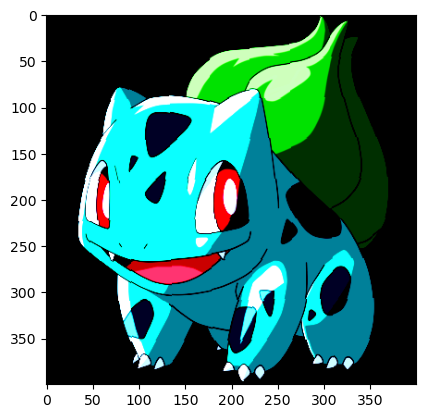

In [7]:
import matplotlib.pyplot as plt
#img, label = dataset[233+238+48+239+234-1]  # Taking a single instance
img, label = dataset[2]
print(img.shape)         # print shape
plt.imshow(img.permute((1, 2, 0))) # plot image
print('Label (numeric):', label)
print('Label (textual):', pkm_names[label])




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


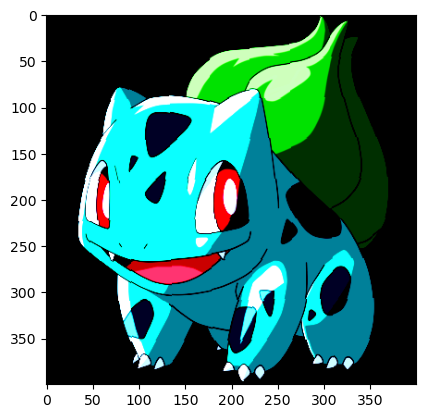

In [17]:
tr = transforms.RandomRotation(180)
#tf = transforms.RandomHorizontalFlip()
new_img = tf(img)
plt.imshow(new_img.permute((1, 2, 0))) # plot image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 400, 400])
Label (numeric): 2
Label (textual): gengar


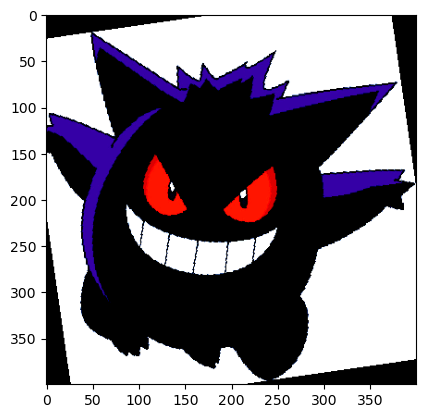

In [18]:
import matplotlib.pyplot as plt
img, label = dataset[500]  # Taking a single instance
print(img.shape)         # print shape
plt.imshow(img.permute((1, 2, 0))) # plot image
print('Label (numeric):', label)
print('Label (textual):', pkm_names[label])

In [19]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [22]:
train_loader = DataLoader(train_dataset, batch_size = 10, shuffle=True, num_workers = 1)
test_loader = DataLoader(test_dataset, batch_size = 10, shuffle=False, num_workers = 1)
images, labels=next(iter(train_loader))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


images.shape: torch.Size([10, 3, 400, 400])


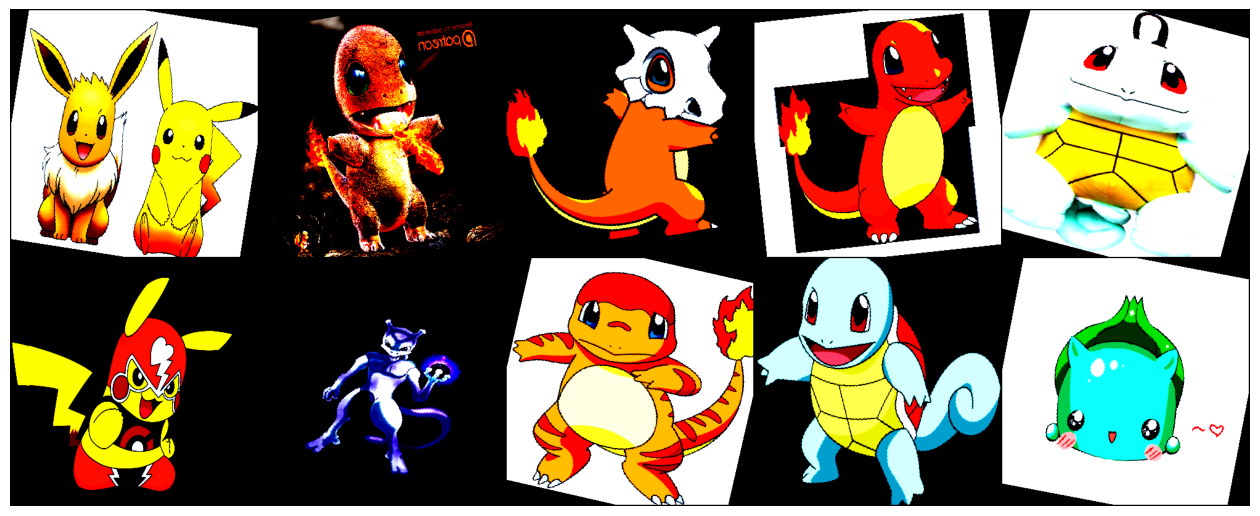

In [23]:
print('images.shape:', images.shape)
plt.figure(figsize=(16,8)) # setting figure size
plt.axis('off')   # we do not was x-ticks and y-ticks
plt.imshow(make_grid(images, nrow=5).permute((1, 2, 0))) # 16 images in a row

# 2. Train Model

In [24]:
from torchvision.models import vgg16, VGG16_Weights
model_pre = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
print(model_pre)

for param in model_pre.parameters():
    param.requires_grad = False

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [25]:
model_pre.classifier[6] = nn.Sequential(
    nn.Linear(4096, 1024), 
    nn.ReLU(), 
    nn.Linear(1024, 256), 
    nn.ReLU(), 
    #nn.Dropout(0.4),
    nn.Linear(256, 6) # 6 classes
)

print(model_pre)
model_pre = model_pre.to(device)
images = images.to(device)
model_pre(images)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

tensor([[ 0.1618,  0.1183,  0.0278, -0.0048, -0.0462,  0.0017],
        [ 0.1416,  0.0595,  0.0495,  0.0107, -0.0501,  0.0186],
        [ 0.1016,  0.0905,  0.0128,  0.0730, -0.0379, -0.1425],
        [ 0.1612,  0.0611,  0.0253,  0.0339, -0.0130, -0.0506],
        [ 0.1364,  0.0747,  0.0430,  0.0124, -0.0665,  0.0783],
        [ 0.1536,  0.0737,  0.0728, -0.0438, -0.0459,  0.0273],
        [ 0.1507,  0.1464,  0.0652, -0.0285, -0.0587, -0.0518],
        [ 0.1514, -0.0074,  0.0234, -0.0318, -0.0779, -0.0099],
        [ 0.0895,  0.0642,  0.0305,  0.0246, -0.0302, -0.0549],
        [ 0.1349,  0.0630, -0.0184,  0.0163, -0.0444, -0.0639]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [26]:
param_num = sum(p.numel() for p in model_pre.parameters())
param_train_num = sum(p.numel() for p in model_pre.parameters() if p.requires_grad)
print(f'total parameters: {param_num}\ntrain parameters: {param_train_num}')


total parameters: 138719814
train parameters: 4459270


In [27]:
from torch import optim
import numpy as np

loss_fn = nn.CrossEntropyLoss()   
loss_fn


optimizer = optim.Adam(model_pre.parameters(), lr = 0.01)   
optimizer

# training parameters
n_epochs = 10  # number of epochs to run
 
# Hold the best model
best_acc = 0   # init to infinity
best_weights = None
history = []
 
# training loop
for epoch in range(n_epochs):
    model_pre.train() # tell pytorch you are training
    for  X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device) # data to gpu
        # forward pass
        y_pred = model_pre(X_train)
        loss = loss_fn(y_pred, y_train)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()

    model_pre.eval() # tell pytorch you are testing
    with torch.no_grad(): # speed up calculation
        total=0
        accuracy=0
        for  X_test, y_test in test_loader: 
            X_test, y_test = X_test.to(device), y_test.to(device) # data to gpu
            y_pred = model_pre(X_test)
            label_pred = torch.max(y_pred,1)[1]
            total = total + len(y_test)
            accuracy = accuracy + (y_test==label_pred).sum()
    history.append([accuracy/total])
    if accuracy/total > best_acc:
        best_acc = accuracy/total
        torch.save(model_pre, "./vgg_pkm_best2.model")
        print("save!")
    print(f'Epoch {epoch}: {accuracy/total}')

/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


save!
Epoch 0: 0.7909835577011108


/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


save!
Epoch 1: 0.856557309627533


/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

save!
Epoch 3: 0.8729507923126221


/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


save!
Epoch 4: 0.8934425711631775


/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/ruiqliu/conda/envs/SML/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


KeyboardInterrupt: 